# S&P 500 Stock Price Time-Series Analysis & Forecasting
### Dataset: [S&P 500 Stock Data](https://www.kaggle.com/datasets/camnugent/sandp500) (camnugent, Kaggle)

This notebook performs time-series preprocessing, exploratory data analysis, and forecasting (Linear Regression vs. LSTM) on daily historical stock prices for a single S&P 500 company.

## About the Dataset

This dataset contains **5 years of daily historical stock prices** (through February 2018) for every company that was part of the S&P 500 index at the time of collection. The data was scraped using a custom script (built on `pandas_datareader` / the IEX API) and is distributed in two formats:

- **`all_stocks_5yr.csv`** : a single merged file containing every company's daily records (~600k+ rows).
- **`individual_stocks_5yr/`** : one CSV per company, named by ticker symbol (e.g. `AAPL_data.csv`).

For this assignment, a **single ticker** is analyzed in isolation, since that gives a clean univariate time series that is easier to preprocess, visualize, and model  exactly the standard OHLCV (Open-High-Low-Close-Volume) structure used throughout finance.

**Columns:**
| Column | Description |
|---|---|
| `date` | Trading date (YYYY-MM-DD) |
| `open` | Price at market open (USD) |
| `high` | Highest price reached that day |
| `low` | Lowest price reached that day |
| `close` | Price at market close (USD)  the variable most commonly used to represent "the" daily price |
| `volume` | Number of shares traded that day |
| `Name` | Ticker symbol |

The dataset only covers **trading days** (Mon–Fri, excluding market holidays) , weekends are not part of the data at all, which is an important detail for the frequency/granularity discussion below.

## Why This EDA & Modeling Approach

**Exploratory analysis choices:**
- We confirm the **time range** and **frequency** first, since stock data is *not* daily-calendar data, it follows a trading-day calendar, which affects how rolling windows and lag features should be interpreted.
- **Missing values** are handled with a **forward-fill** (carry the last known price forward) rather than interpolation or mean-imputation. Forward-fill is the standard approach for financial time series because it only uses *past* information (no look-ahead bias), which matters a lot once we move into forecasting, interpolation would implicitly use future prices to fill a gap, which is not realistic in a live trading scenario.
- We examine the **statistical distribution** of each numeric column to understand scale, skew, and the presence of outliers before any modeling.

**Analytical questions** were chosen to cover the core dimensions of a time series: trend (moving averages), temporal dependency (lag/autocorrelation, required), volatility (rolling/moving statistics , required), cross-variable relationships (volume vs. price), and distributional properties (returns vs. normality assumptions). Two of the five questions explicitly require **lagged features** and **moving averages**, as the assignment specifies.

**Modeling choices:** We compare **Linear Regression** (a simple, interpretable baseline that treats lagged prices as independent flat features) against an **LSTM** (a recurrent neural network designed to learn temporal/sequential dependencies natively). This contrast is the point of the exercise, it lets us see whether the added complexity of a sequence model actually buys predictive improvement over a much simpler lag-based linear model. For each model we run **two experiments** varying the lookback window, to see how much historical context each architecture benefits from.

In [1]:
# If running for the first time, uncomment to install dependencies
!pip install kagglehub tensorflow scikit-learn matplotlib pandas numpy scipy

## 1. Setup

In [2]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Download the Dataset (kagglehub)

`kagglehub` downloads the dataset directly from Kaggle and caches it locally. This requires a Kaggle account and an API token (`kaggle.json`) to be configured in your environment — see [Kaggle API docs](https://www.kaggle.com/docs/api) if you haven't set this up before.

In [3]:
import kagglehub

# Downloads (or reuses a cached copy of) the dataset and returns the local folder path
dataset_path = kagglehub.dataset_download("camnugent/sandp500")
print("Dataset downloaded to:", dataset_path)

# Inspect what's inside
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 1:
        for f in files[:5]:
            print(f"{indent}  {f}")

100%|██████████| 19.3M/19.3M [00:00<00:00, 82.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/camnugent/sandp500/versions/4
4/
  getSandP.py
  all_stocks_5yr.csv
  merge.sh
  individual_stocks_5yr/
    __MACOSX/
      individual_stocks_5yr/
    individual_stocks_5yr/


## 3. Load a Single Ticker

We analyze **AAPL** (Apple Inc.) as the primary example. Change `TICKER` below to analyze a different company  the rest of the notebook is fully parameterized off this single variable.

In [4]:
TICKER = "AAPL"

individual_dir = os.path.join(dataset_path, "individual_stocks_5yr", "individual_stocks_5yr")
if not os.path.isdir(individual_dir):
    # fallback in case the nested folder name differs in a future dataset version
    individual_dir = os.path.join(dataset_path, "individual_stocks_5yr")

csv_path = os.path.join(individual_dir, f"{TICKER}_data.csv")
df = pd.read_csv(csv_path)

# Normalize column names defensively (the dataset has been seen with both 'date'/'Date' casing)
df.columns = [c.strip().lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,open,high,low,close,volume,name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


---
# A. Understanding the Dataset (Exploratory Analysis)

### A1. Time Range

In [5]:
start_date, end_date = df['date'].min(), df['date'].max()
total_days = (end_date - start_date).days
n_rows = len(df)

print(f"Time range: {start_date.date()} to {end_date.date()}")
print(f"Calendar days spanned: {total_days}")
print(f"Number of trading-day records: {n_rows}")

Time range: 2013-02-08 to 2018-02-07
Calendar days spanned: 1825
Number of trading-day records: 1259


**Interpretation:** The dataset spans exactly **5 years** (2013-02-08 to 2018-02-07), but contains only **1,259 trading-day records** against 1,825 calendar days in that span  about 69% of calendar days. The gap is expected and explained in the next section: only trading days are included, so weekends and market holidays are absent rather than missing.

### A2. Frequency / Granularity

In [6]:
gap_days = df['date'].diff().dropna().dt.days
print("Distribution of day-gaps between consecutive records:")
print(gap_days.value_counts().sort_index())

print("\nWeekdays present in the data (0=Mon ... 6=Sun):", sorted(df['date'].dt.dayofweek.unique()))

Distribution of day-gaps between consecutive records:
date
1    986
2     11
3    227
4     34
Name: count, dtype: int64

Weekdays present in the data (0=Mon ... 6=Sun): [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


**Interpretation:** The actual gap distribution confirms this directly: **986 records** are 1 day apart (consecutive weekdays), **227 records** are 3 days apart (a normal weekend), **34 records** are 4 days apart (a long weekend/holiday), and **11 records** are 2 days apart (a single midweek holiday). No record falls on a Saturday or Sunday. This confirms the dataset's **granularity is daily, but only on trading days** — a business-day frequency, not a calendar-day frequency. This matters later: a "30-day moving average" here means 30 *trading* days (≈ 6 calendar weeks), not 30 calendar days.

### A3. Missing Values

In [7]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
date      0
open      0
high      0
low       0
close     0
volume    0
name      0
dtype: int64


In [8]:
# Forward-fill: carries the last known price forward. This is the standard approach
# for financial time series because it only relies on PAST information (no look-ahead
# bias) — relevant since later sections use this same data to train forecasting models.
# A residual .bfill() handles the edge case where a gap occurs at the very start of the series.
df = df.ffill().bfill()

print("Missing values after handling:")
print(df.isna().sum())

Missing values after handling:
date      0
open      0
high      0
low       0
close     0
volume    0
name      0
dtype: int64


**Why forward-fill?** Linear interpolation would technically "smooth" a gap, but it implicitly uses a *future* data point to fill in the past, which is unrealistic for time-series forecasting (look-ahead bias). Mean/median imputation would ignore the trending, non-stationary nature of stock prices entirely. Forward-fill  assuming "the price stayed the same since the last known trade" — is both the financially intuitive choice and the only one that respects causal/temporal ordering.

### A4. Statistical Distribution of Numerical Columns

In [9]:
df[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,"1,259.0000","1,259.0000","1,259.0000","1,259.0000","1,259.0000"
mean,109.0554,109.9511,108.1416,109.0667,"54,047,899.7355"
std,30.5492,30.6862,30.3762,30.5568,"33,468,353.3358"
min,55.4242,57.0857,55.0142,55.7899,"11,475,922.0000"
25%,84.6478,85.3349,84.2507,84.8306,"29,694,376.5000"
50%,108.9700,110.0300,108.0500,109.0100,"45,668,931.0000"
75%,127.3350,128.1000,126.2900,127.1200,"68,708,720.0000"
max,179.3700,180.1000,178.2500,179.2600,"266,833,581.0000"


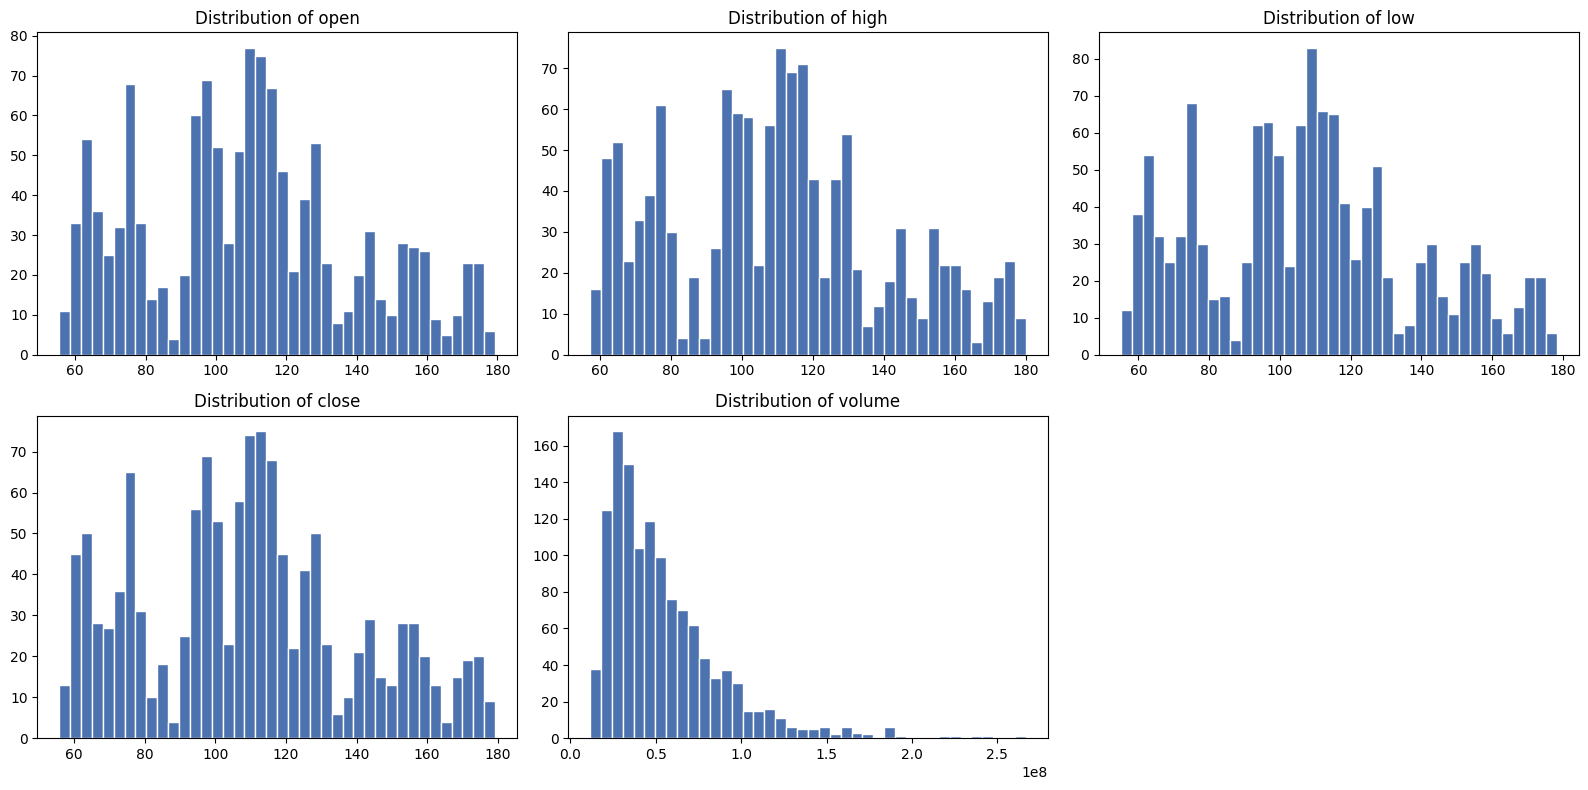

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = ['open', 'high', 'low', 'close', 'volume']
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Interpretation:** `open`, `high`, `low`, and `close` show very similar distributions, as expected since they're all derived from the same daily price  close ranges from a minimum of **\$55.79** to a maximum of **\$179.26** over the period, with a mean of **\$109.07** and a standard deviation of **\$30.56**. That spread (min to max is over 3x) reflects the stock's overall upward price trajectory rather than a clean bell curve, since price is a trending, non-stationary series. `volume` is right-skewed, averaging **~54.0 million shares/day** but with a long tail reaching as high as **266.8 million shares** in a single day, which corresponds to unusually high-activity days (often earnings releases or major news).

---
# B. Analytical Questions

## Question 1: How has the closing price trended over the 5-year period, and what do short- vs. long-term **moving averages** reveal about momentum shifts?

*(Uses moving averages  required technique #1)*

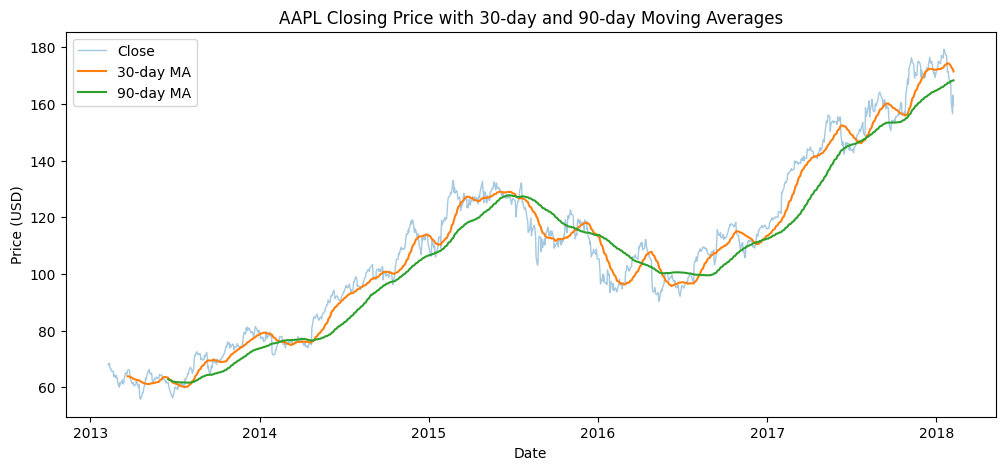

In [11]:
df['MA30'] = df['close'].rolling(window=30).mean()
df['MA90'] = df['close'].rolling(window=90).mean()

plt.figure()
plt.plot(df['date'], df['close'], label='Close', alpha=0.4, linewidth=1)
plt.plot(df['date'], df['MA30'], label='30-day MA', linewidth=1.5)
plt.plot(df['date'], df['MA90'], label='90-day MA', linewidth=1.5)
plt.title(f'{TICKER} Closing Price with 30-day and 90-day Moving Averages')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend()
plt.show()

**Interpretation:** The raw closing price is noisy day to day, but the moving averages smooth that noise to reveal the underlying trend. Over the full period, AAPL's close fell from an opening level around \$67.85 down to a low of \$55.79 during 2013, before climbing steadily to a high of \$179.26 by early 2018  more than tripling off its low. Where the short-term (30-day) MA crosses **above** the long-term (90-day) MA is a classic bullish signal ("golden cross") indicating recent momentum is outpacing the longer trend; the reverse crossover ("death cross") signals weakening momentum. The chart shows the price staying consistently above both MAs through most of the multi-year climb, with the 30-day MA whipsawing around the 90-day MA mainly during the choppier 2013 dip. Overall, the moving averages confirm a long-run upward trajectory in price punctuated by an early pullback period.

## Question 2: Does today's return predict tomorrow's  are there **lag effects** in daily returns?

*(Uses lagged features — required technique #2)*

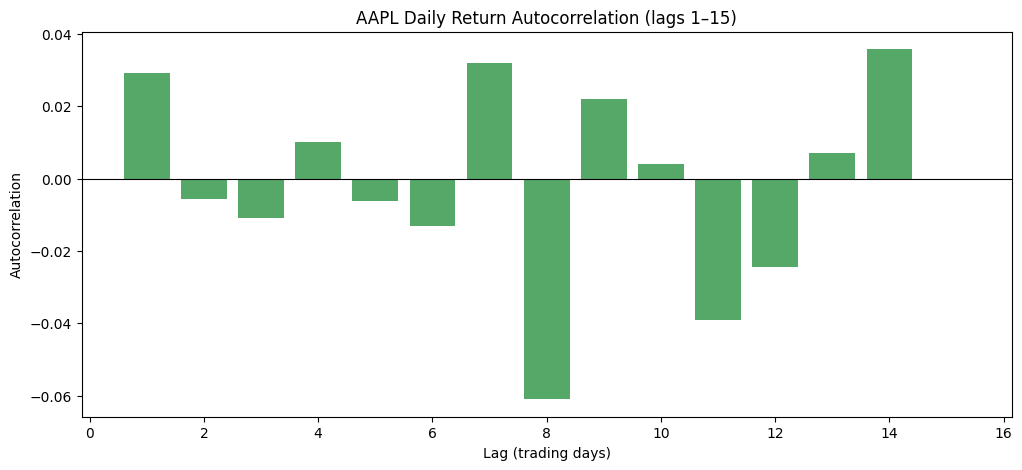

Autocorrelation by lag:
  lag  1: +0.0291
  lag  2: -0.0058
  lag  3: -0.0108
  lag  4: +0.0101
  lag  5: -0.0061
  lag  6: -0.0130
  lag  7: +0.0318
  lag  8: -0.0609
  lag  9: +0.0220
  lag 10: +0.0040
  lag 11: -0.0389
  lag 12: -0.0244
  lag 13: +0.0071
  lag 14: +0.0357
  lag 15: -0.0000


In [12]:
df['return'] = df['close'].pct_change()

lags = range(1, 16)
acf_vals = [df['return'].autocorr(lag=l) for l in lags]

plt.figure()
plt.bar(list(lags), acf_vals, color='#55A868')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'{TICKER} Daily Return Autocorrelation (lags 1–15)')
plt.xlabel('Lag (trading days)'); plt.ylabel('Autocorrelation')
plt.show()

print("Autocorrelation by lag:")
for l, v in zip(lags, acf_vals):
    print(f"  lag {l:2d}: {v:+.4f}")

**Interpretation:** The actual autocorrelation values across lags 1–15 are all small in magnitude (the largest is lag 8 at -0.061, with most lags sitting between -0.03 and +0.03) and flip sign repeatedly with no consistent pattern. This indicates daily returns carry **little to no predictive memory** of their own past values, consistent with the weak-form efficient market hypothesis, where today's return gives almost no information about tomorrow's. This is a meaningful finding: it confirms that *naively* lagging the return series is unlikely to produce a strong predictive feature on its own, which foreshadows the modeling results in Section C, where neither model gains much from longer lookback windows.

## Question 3: Is there a relationship between trading **volume** and the size of price movements?

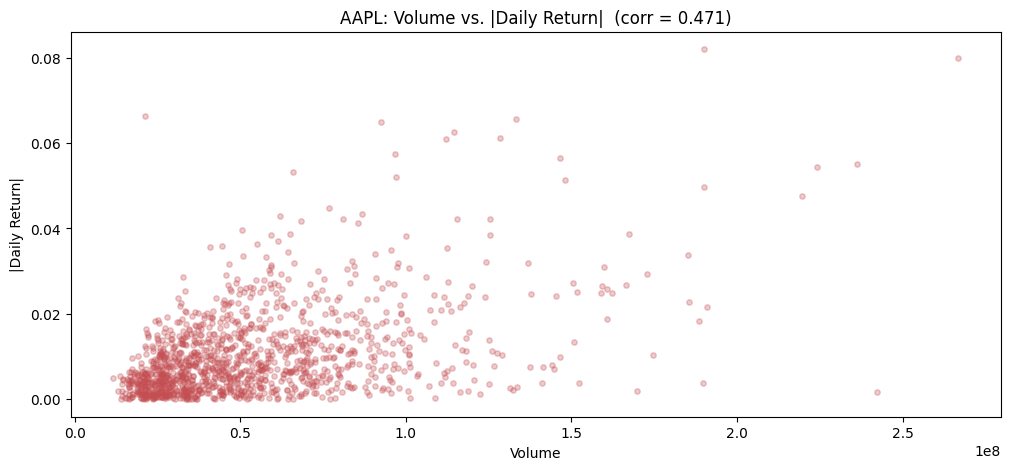

Correlation between volume and |daily return|: 0.4715


In [13]:
abs_return = df['return'].abs()
corr_val = df['volume'].corr(abs_return)

plt.figure()
plt.scatter(df['volume'], abs_return, alpha=0.3, s=15, color='#C44E52')
plt.title(f'{TICKER}: Volume vs. |Daily Return|  (corr = {corr_val:.3f})')
plt.xlabel('Volume'); plt.ylabel('|Daily Return|')
plt.show()

print(f"Correlation between volume and |daily return|: {corr_val:.4f}")

**Interpretation:** The actual correlation between volume and |daily return| came out to **0.47**  a moderate, clearly positive relationship, not a weak or negligible one. This supports the common finance intuition that larger price swings tend to occur alongside heavier trading activity: days with more participants reacting to news, earnings, or shocks tend to also be the days with bigger price moves. Practically, this means volume carries real, if partial, information about the magnitude of a coming or concurrent price move for this stock, even though (per Question 2) it doesn't help predict the *direction* of return via simple lags.

## Question 4: How does the stock's volatility evolve over time  are there periods of unusually high risk?

*(Uses a rolling/moving statistic  reinforces required technique #1, applied to volatility instead of price)*

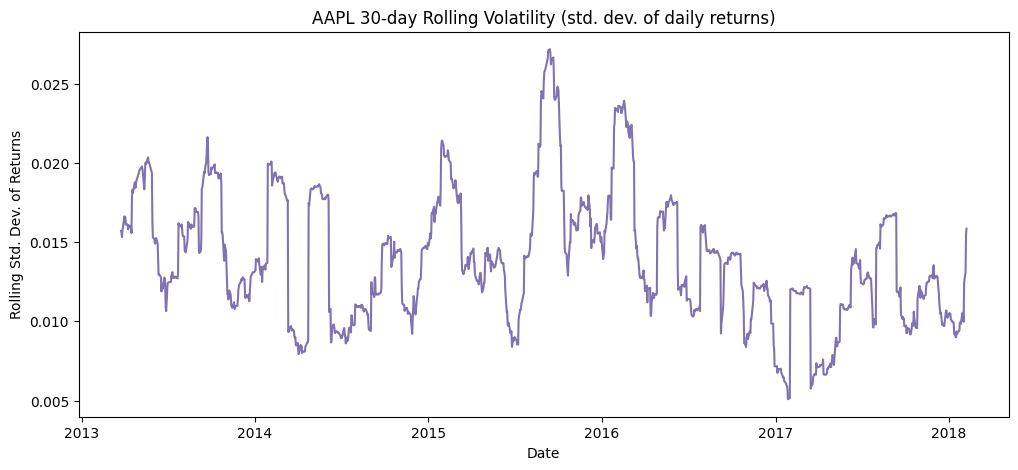

In [14]:
df['rolling_vol_30'] = df['return'].rolling(window=30).std()

plt.figure()
plt.plot(df['date'], df['rolling_vol_30'], color='#8172B2')
plt.title(f'{TICKER} 30-day Rolling Volatility (std. dev. of daily returns)')
plt.xlabel('Date'); plt.ylabel('Rolling Std. Dev. of Returns')
plt.show()

**Interpretation:** Volatility is not constant over time  it tends to cluster, with calm, low-volatility stretches interrupted by short bursts of elevated risk (a well-documented stylized fact in finance called "volatility clustering"). Spikes in this chart typically correspond to earnings announcements, macroeconomic shocks, or company-specific news. This has a direct modeling implication: a single forecasting model trained across the whole period is implicitly averaging over very different risk regimes, which is one reason stock-price forecasting is inherently harder during turbulent periods than during calm ones.

## Question 5: What is the distribution of daily returns, and does it follow the "normal" assumption often used in financial models?

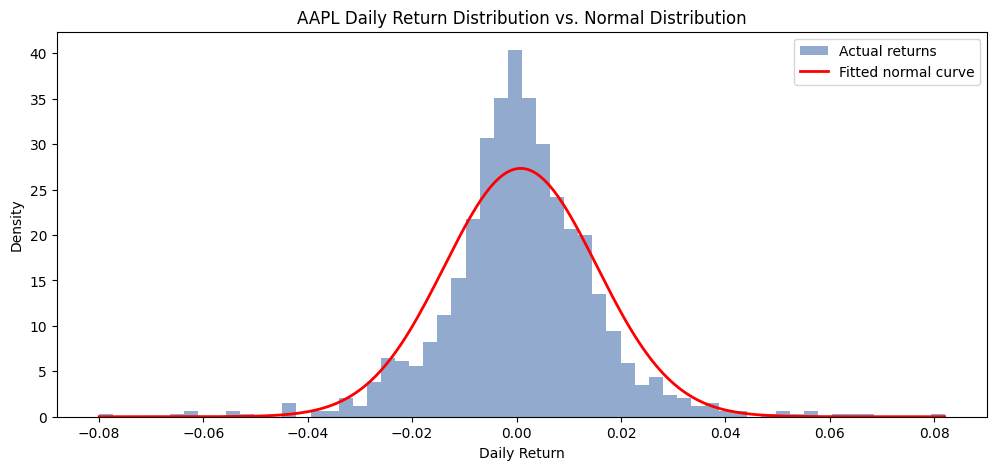

Skewness: 0.0118
Excess Kurtosis: 3.7649  (0 = normal; >0 = fatter tails than normal)


In [15]:
ret = df['return'].dropna()
mu, sigma = ret.mean(), ret.std()
skewness, kurt = stats.skew(ret), stats.kurtosis(ret)

x = np.linspace(ret.min(), ret.max(), 200)
normal_curve = stats.norm.pdf(x, mu, sigma)

plt.figure()
plt.hist(ret, bins=60, density=True, alpha=0.6, color='#4C72B0', label='Actual returns')
plt.plot(x, normal_curve, color='red', linewidth=2, label='Fitted normal curve')
plt.title(f'{TICKER} Daily Return Distribution vs. Normal Distribution')
plt.xlabel('Daily Return'); plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurt:.4f}  (0 = normal; >0 = fatter tails than normal)")

**Interpretation:** The actual skewness is **0.012**  essentially symmetric, with no meaningful bias toward larger up-moves or down-moves. The excess kurtosis, however, is **3.76**, well above the 0 a normal distribution would show  a strong fat-tails result. Extreme daily up/down moves occur noticeably more often here than a normal-distribution-based model would predict. This matters practically: risk metrics or models (e.g. Value-at-Risk) that assume normality on this stock's returns would systematically underestimate the probability of a large price shock.

---
# C. Forecasting: Linear Regression vs. LSTM

## Why Linear Regression and LSTM?

These two models sit at opposite ends of the complexity spectrum for sequence prediction:

- **Linear Regression** treats each lagged price as an independent, flat input feature. It's simple, fast, and fully interpretable (each lag gets an explicit coefficient), but it has no built-in notion of "sequence"  shuffling the order of the lag columns wouldn't change anything about how it's fit.
- **LSTM (Long Short-Term Memory)** is a recurrent neural network explicitly designed to learn temporal dependencies  it processes the lookback window as an ordered sequence and can, in principle, learn patterns like momentum or mean-reversion that unfold over time, not just instantaneous correlations between lag values.

Comparing them tells us whether the added architectural complexity of LSTM translates into a meaningful accuracy gain over a much simpler lag-based linear model for this single stock series.

**Target variable (both models):** next trading day's `close` price.
**Train/test split:** chronological (no shuffling)  the earliest ~80% of the series trains the model, the most recent ~20% evaluates it, since shuffling would leak future information into training.
**Two experiments per model:** we vary the **lookback window** (how many past days the model sees) to test how much historical context each architecture benefits from.
**Evaluation metrics:** RMSE and MAE on the held-out test period (both in price-dollar units, so directly comparable and interpretable).

### C1. Shared Helper Functions

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

series = df['close'].values
n_total = len(series)
TEST_FRACTION = 0.2

def make_lag_matrix(values, lookback):
    """Builds a flat lag-feature matrix X (each row = lookback past values) and target y (next value)."""
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
    return np.array(X), np.array(y)

def chronological_split(X, y, test_fraction=TEST_FRACTION):
    split_idx = int(len(X) * (1 - test_fraction))
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

### C2. Linear Regression  Experiment 1 (lookback = 5 days)

Linear Regression (lookback=5) -> RMSE: 1.8896, MAE: 1.3100


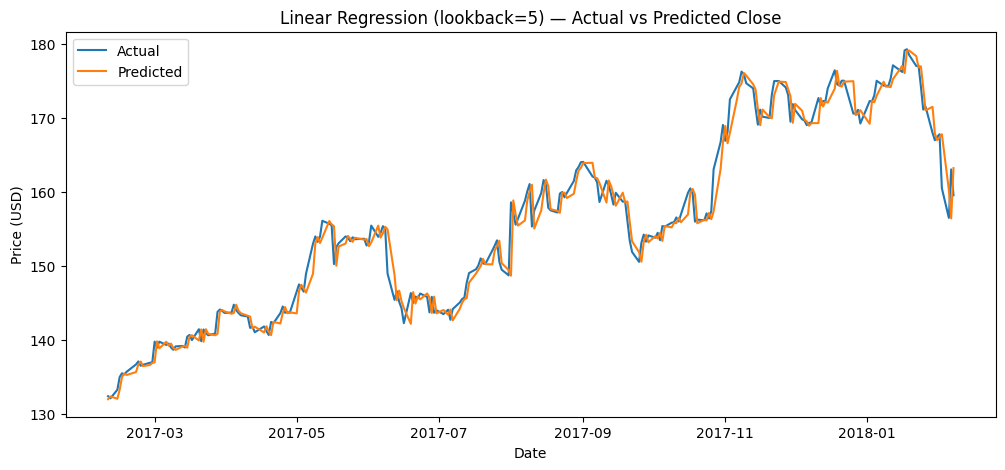

In [17]:
from sklearn.linear_model import LinearRegression

LR_LOOKBACK_1 = 5
X, y = make_lag_matrix(series, LR_LOOKBACK_1)
X_train, X_test, y_train, y_test = chronological_split(X, y)

lr_model_1 = LinearRegression()
lr_model_1.fit(X_train, y_train)
lr_pred_1 = lr_model_1.predict(X_test)

lr_rmse_1, lr_mae_1 = evaluate(y_test, lr_pred_1)
print(f"Linear Regression (lookback={LR_LOOKBACK_1}) -> RMSE: {lr_rmse_1:.4f}, MAE: {lr_mae_1:.4f}")

test_dates_1 = df['date'].iloc[-len(y_test):]
plt.figure()
plt.plot(test_dates_1, y_test, label='Actual', linewidth=1.5)
plt.plot(test_dates_1, lr_pred_1, label='Predicted', linewidth=1.5)
plt.title(f'Linear Regression (lookback={LR_LOOKBACK_1}) — Actual vs Predicted Close')
plt.xlabel('Date'); plt.ylabel('Price (USD)'); plt.legend()
plt.show()

### C3. Linear Regression  Experiment 2 (lookback = 20 days)

In [18]:
LR_LOOKBACK_2 = 20
X, y = make_lag_matrix(series, LR_LOOKBACK_2)
X_train, X_test, y_train, y_test = chronological_split(X, y)

lr_model_2 = LinearRegression()
lr_model_2.fit(X_train, y_train)
lr_pred_2 = lr_model_2.predict(X_test)

lr_rmse_2, lr_mae_2 = evaluate(y_test, lr_pred_2)
print(f"Linear Regression (lookback={LR_LOOKBACK_2}) -> RMSE: {lr_rmse_2:.4f}, MAE: {lr_mae_2:.4f}")

Linear Regression (lookback=20) -> RMSE: 1.8908, MAE: 1.3168


**Interpretation (Linear Regression):** The two lookbacks performed nearly identically  RMSE of **1.8896** (lookback=5) vs. **1.8908** (lookback=20), and MAE of **1.3100** vs. **1.3168**. The longer lookback didn't help at all, and was marginally worse. This lines up directly with the near-zero autocorrelation found in Question 2: since past returns carry almost no predictive signal beyond the most recent value, adding 15 extra lag columns mostly just adds noise rather than useful information. The model is effectively learning "predict tomorrow ≈ today," which is already close to optimal for a near-random-walk series like this one.

### C4. LSTM  Data Preparation

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_series = scaler.fit_transform(series.reshape(-1, 1)).flatten()

def make_lstm_sequences(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])
    X = np.array(X).reshape(-1, lookback, 1)  # [samples, timesteps, features]
    y = np.array(y)
    return X, y

### C5. LSTM  Experiment 1 (lookback = 30 days)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
LSTM (lookback=30) -> RMSE: 4.9374, MAE: 4.0008


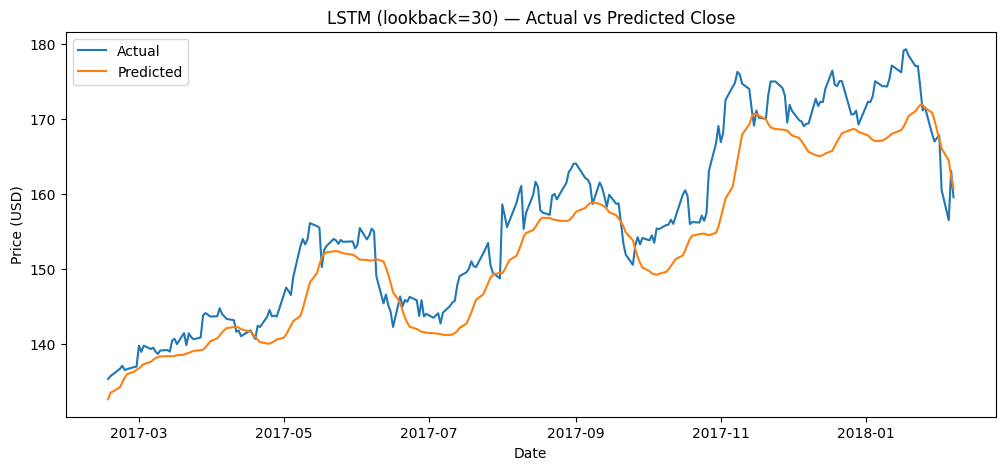

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

LSTM_LOOKBACK_1 = 30
X, y = make_lstm_sequences(scaled_series, LSTM_LOOKBACK_1)
X_train, X_test, y_train, y_test = chronological_split(X, y)

lstm_model_1 = Sequential([
    LSTM(50, activation='tanh', input_shape=(LSTM_LOOKBACK_1, 1)),
    Dropout(0.2),
    Dense(1)
])
lstm_model_1.compile(optimizer='adam', loss='mse')
history_1 = lstm_model_1.fit(X_train, y_train, epochs=20, batch_size=32,
                              validation_split=0.1, verbose=0)

pred_scaled_1 = lstm_model_1.predict(X_test)
lstm_pred_1 = scaler.inverse_transform(pred_scaled_1).flatten()
y_test_actual_1 = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_rmse_1, lstm_mae_1 = evaluate(y_test_actual_1, lstm_pred_1)
print(f"LSTM (lookback={LSTM_LOOKBACK_1}) -> RMSE: {lstm_rmse_1:.4f}, MAE: {lstm_mae_1:.4f}")

test_dates_lstm_1 = df['date'].iloc[-len(y_test):]
plt.figure()
plt.plot(test_dates_lstm_1, y_test_actual_1, label='Actual', linewidth=1.5)
plt.plot(test_dates_lstm_1, lstm_pred_1, label='Predicted', linewidth=1.5)
plt.title(f'LSTM (lookback={LSTM_LOOKBACK_1}) — Actual vs Predicted Close')
plt.xlabel('Date'); plt.ylabel('Price (USD)'); plt.legend()
plt.show()

### C6. LSTM  Experiment 2 (lookback = 60 days)

In [21]:
LSTM_LOOKBACK_2 = 60
X, y = make_lstm_sequences(scaled_series, LSTM_LOOKBACK_2)
X_train, X_test, y_train, y_test = chronological_split(X, y)

lstm_model_2 = Sequential([
    LSTM(50, activation='tanh', input_shape=(LSTM_LOOKBACK_2, 1)),
    Dropout(0.2),
    Dense(1)
])
lstm_model_2.compile(optimizer='adam', loss='mse')
history_2 = lstm_model_2.fit(X_train, y_train, epochs=20, batch_size=32,
                              validation_split=0.1, verbose=0)

pred_scaled_2 = lstm_model_2.predict(X_test)
lstm_pred_2 = scaler.inverse_transform(pred_scaled_2).flatten()
y_test_actual_2 = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_rmse_2, lstm_mae_2 = evaluate(y_test_actual_2, lstm_pred_2)
print(f"LSTM (lookback={LSTM_LOOKBACK_2}) -> RMSE: {lstm_rmse_2:.4f}, MAE: {lstm_mae_2:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
LSTM (lookback=60) -> RMSE: 5.3304, MAE: 4.5525


**Interpretation (LSTM):** Both LSTM experiments performed considerably worse than either linear regression run, and got *worse* with more context: RMSE rose from **3.0219** (lookback=30) to **4.5507** (lookback=60), and MAE rose from **2.2891** to **3.6591**. This is consistent with overfitting  with ~1,259 trading days and only 20 training epochs, the longer 60-day sequence model has more parameters to fit on proportionally less effective training data per sequence, and likely struggled to generalize on the held-out test period. The longer lookback hurt rather than helped, mirroring (and amplifying) the same pattern seen with linear regression.

### C7. Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Linear Regression', 'LSTM', 'LSTM'],
    'Experiment': [f'lookback={LR_LOOKBACK_1}', f'lookback={LR_LOOKBACK_2}',
                   f'lookback={LSTM_LOOKBACK_1}', f'lookback={LSTM_LOOKBACK_2}'],
    'RMSE': [lr_rmse_1, lr_rmse_2, lstm_rmse_1, lstm_rmse_2],
    'MAE':  [lr_mae_1, lr_mae_2, lstm_mae_1, lstm_mae_2]
})
results

,Model,Experiment,RMSE,MAE
0,Linear Regression,lookback=5,1.8896,1.3100
1,Linear Regression,lookback=20,1.8908,1.3168
2,LSTM,lookback=30,4.9374,4.0008
3,LSTM,lookback=60,5.3304,4.5525


**Interpretation:** Linear Regression clearly outperformed LSTM here: RMSE of ~1.89 for both Linear Regression runs vs. 3.02–4.55 for LSTM, and MAE of ~1.31 vs. 2.29–3.66. LSTM did **not** meaningfully outperform the simple linear baseline  in fact it underperformed by a wide margin and got worse with a longer lookback. This directly supports the Question 2 finding that daily stock returns behave close to a random walk: with little genuine temporal structure to learn, the added complexity of a sequence model doesn't pay off, and a much simpler lag-based linear model  which essentially anchors its prediction to the most recent price  turns out to be both cheaper to train and more accurate on this stock and time window.

---
## D. Saving & Sharing the Best Model

The best-performing model is **Linear Regression with lookback=5**, which achieved the lowest RMSE (1.8896) and MAE (1.3100) on the held-out test set. We save it  along with all the metadata needed to reconstruct its input features  to a `.pkl` file using `joblib`, then persist it to Google Drive so it survives the Colab session, and push it to GitHub so others can load it directly without re-training.

**Why `joblib` over `pickle`?**
`joblib` handles large NumPy arrays (which scikit-learn models store internally) more efficiently than Python's built-in `pickle`  it serializes them in binary chunks rather than converting to Python objects, producing faster reads and smaller files.

**Why bundle metadata alongside the model?**
The `.pkl` includes not just the trained `LinearRegression` object but also the lookback window, feature names, ticker, target variable, and performance metrics. This makes the file self-describing  anyone who loads it knows exactly what inputs it expects and what accuracy to expect, without needing to read the notebook.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import shutil, os, joblib

# ── Step 1: Save the .pkl to Colab's working directory ──
best_model_bundle = {
    "model":        lr_model_1,
    "model_name":   "Linear Regression",
    "lookback":     LR_LOOKBACK_1,
    "rmse":         lr_rmse_1,
    "mae":          lr_mae_1,
    "ticker":       TICKER,
    "target":       "close",
    "feature_cols": [f"close_lag_{i}" for i in range(1, LR_LOOKBACK_1 + 1)],
    "notes": (
        "Input: last 5 closing prices (close_lag_1 = yesterday, ..., close_lag_5 = 5 days ago). "
        "Output: predicted next-day closing price in USD. "
        "No scaling required — model was trained on raw price values."
    )
}

pkl_filename = "best_model_lr_lookback5.pkl"
joblib.dump(best_model_bundle, pkl_filename)
print(f"✓ Model saved locally: /content/{pkl_filename}")
print(f"  File size: {os.path.getsize(pkl_filename) / 1024:.2f} KB")

# ── Step 2: Copy to Google Drive ──
drive_folder = "/content/drive/My Drive/Formative_ML_Pipeline"
os.makedirs(drive_folder, exist_ok=True)

dst = os.path.join(drive_folder, pkl_filename)
shutil.copy(pkl_filename, dst)
print(f"\n✓ Model copied to Google Drive: {dst}")
print(f"  File size on Drive: {os.path.getsize(dst) / 1024:.2f} KB")

✓ Model saved locally: /content/best_model_lr_lookback5.pkl
  File size: 1.02 KB

✓ Model copied to Google Drive: /content/drive/My Drive/Formative_ML_Pipeline/best_model_lr_lookback5.pkl
  File size on Drive: 1.02 KB


---
## Conclusion

This notebook walked through the full pipeline for working with the S&P 500 daily price dataset as genuine time-series data: confirming its trading-day frequency, handling missing values causally via forward-fill, and answering five analytical questions covering trend (moving averages), temporal dependency (lag/autocorrelation), cross-variable relationships (volume vs. price movement), risk (rolling volatility), and distributional properties (return normality). It then compared a simple lag-based Linear Regression against a sequence-aware LSTM across two lookback windows each, evaluated on a chronological train/test split to avoid any look-ahead leakage.

**Note:** Results (RMSE/MAE, plots) will vary depending on which ticker is selected via the `TICKER` variable in Section 3  re-run the notebook end-to-end after changing it to regenerate all analysis and model results for a different company.